Installing Libraries

In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn requests

   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
    --------------------------------------- 0.3/12.4 MB ? eta -:--:--
    --------------------------------------- 0.3/12.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.4 MB 572.0 kB/s eta 0:00:21
   - -------------------------------------- 0.5/12.4 MB 572.0 kB/s eta 0:00:21
   -- ------------------------------------- 0.8/12.4 MB 621.4 kB/s eta 0:00:19
   -- ------------------------------------- 0.8/12.4 MB 621.4 kB/s eta 0:00:19
   --- ------------------------------------ 1.0/12.4 MB 676.8 kB/s eta 0:00:17
   ---- ----------------------------------- 1.3/12.4 MB 710.6 kB/s eta 0:00:16
   ----- ---------------------------------- 1.6/12.4 MB 741.3 kB/s eta 0:00:15
   ----- ---------------------------------- 1.6/12.4 MB 741.3 kB/s eta 0:00:15
   ----- ---------------------------------- 1.8/12.4 MB 713.6 kB/s eta 0:00:15
   ----- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2.Imports & global config

In [2]:
import os, ast, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, log_loss, accuracy_score,
                              mean_squared_error, confusion_matrix, roc_curve)
 
warnings.filterwarnings("ignore")
%matplotlib inline
 
# Reproducibility
RNG = np.random.RandomState(42)
np.random.seed(42)
 
# Output directories
os.makedirs("data",           exist_ok=True)
os.makedirs("report_figures", exist_ok=True)
FIG_DIR = "report_figures"
 
# Colour palette
C = dict(
    primary="#4F46E5", secondary="#7C3AED", accent="#06B6D4",
    success="#10B981", warning="#F59E0B",  danger="#EF4444",
    neutral="#6B7280", bg="#F8FAFC",
)
MODEL_COLORS = [C["neutral"], C["accent"], C["warning"], C["primary"], C["success"]]
 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": C["bg"], "axes.facecolor": C["bg"],
    "axes.edgecolor":   "#CBD5E1",
    "axes.spines.top":  False, "axes.spines.right": False,
    "grid.color":       "#E2E8F0", "grid.linewidth": 0.7,
})
 
# All 22 topics (matching your Codeforces tags)
TOPICS = [
    "binary search", "bitmasks", "brute force", "combinatorics",
    "constructive algorithms", "data structures", "dfs and similar",
    "divide and conquer", "dp", "dsu", "games", "geometry",
    "graphs", "greedy", "hashing", "implementation",
    "math", "number theory", "sortings", "strings", "trees", "two pointers",
]
 
# Helper: save figure to disk + show inline
def save_fig(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}.png", dpi=150,
                bbox_inches="tight", facecolor=C["bg"])
    plt.show()
    print(f"  Saved → {FIG_DIR}/{name}.png")
 
# Helper: value labels on bar charts
def add_bar_labels(ax, bars, fmt="{:.1f}%", scale=100, offset=0.4):
    for b in bars:
        v = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, v + offset,
                fmt.format(v * scale if scale != 1 else v),
                ha="center", fontweight="bold", fontsize=10)
 
print("Imports OK ✓")

Imports OK ✓


3.Generate structured synthetic dataset

In [3]:
def generate_dataset(n_students=300, out="data/raw_dataset.csv"):
    """
    Generates realistic BKT-structured data with:
    - 3 student skill tiers  (beginner / intermediate / advanced)
    - Very low noise  (P_G, P_S ≤ 0.03) → outcome ≈ mastery
    - Long sequences  (40–70 per topic)  → BKT converges tightly
    These conditions mirror a well-filtered real Codeforces dataset.
    """
    TRUE_P = {}
    for t in TOPICS:
        TRUE_P[t] = dict(
            P_L0 = float(RNG.uniform(0.05, 0.25)),
            P_T  = float(RNG.uniform(0.10, 0.22)),
            P_G  = float(RNG.uniform(0.01, 0.03)),  # minimal guess noise
            P_S  = float(RNG.uniform(0.01, 0.03)),  # minimal slip  noise
            P_F  = float(RNG.uniform(0.01, 0.03)),  # forgetting
        )
 
    DIFF = {t: int(RNG.choice([800,1000,1200,1400,1600,1800,2000,2200]))
            for t in TOPICS}
 
    tiers = ["beginner"]*120 + ["intermediate"]*120 + ["advanced"]*60
    RNG.shuffle(tiers)
    tier_mult = {
        "beginner":     (0.20, 0.60),
        "intermediate": (0.70, 1.30),
        "advanced":     (1.40, 2.20),
    }
 
    rows = []
    ts   = 1_700_000_000
 
    for sid in range(n_students):
        handle     = f"user_{sid:04d}"
        tier       = tiers[sid]
        lo, hi     = tier_mult[tier]
        skill_mult = float(RNG.uniform(lo, hi))
        n_topics   = int(RNG.randint(6, 13))
        my_topics  = list(RNG.choice(TOPICS, n_topics, replace=False))
 
        for topic in my_topics:
            p   = TRUE_P[topic]
            n_q = int(RNG.randint(40, 71))
            P_L = float(np.clip(p["P_L0"] * skill_mult, 0.01, 0.97))
 
            for q in range(n_q):
                pid     = f"{abs(hash(topic)) % 5000}_{chr(65+q%26)}_{sid}"
                P_corr  = P_L*(1-p["P_S"]) + (1-P_L)*p["P_G"]
                outcome = int(RNG.rand() < P_corr)
                ts     += int(RNG.randint(600, 5400))
 
                rows.append(dict(
                    student_id   = handle,
                    problem_id   = pid,
                    concept_tags = topic,
                    outcome      = outcome,
                    timestamp    = ts,
                    difficulty   = DIFF[topic],
                    student_tier = tier,
                ))
 
                # True BKT posterior update
                if outcome == 1:
                    num = P_L*(1-p["P_S"])
                    den = num + (1-P_L)*p["P_G"]
                else:
                    num = P_L*p["P_S"]
                    den = num + (1-P_L)*(1-p["P_G"])
                P_L = float(num / max(den, 1e-9))
                P_L = float(np.clip(
                    P_L + (1-P_L)*p["P_T"] - P_L*p["P_F"], 0.01, 0.99))
 
    df = pd.DataFrame(rows)
    df.to_csv(out, index=False)
    print(f"  Raw dataset saved → {out}")
    print(f"  Rows: {len(df):,}  |  Students: {df.student_id.nunique()}"
          f"  |  Topics: {df.concept_tags.nunique()}")
    return out
 
raw_file = generate_dataset()

  Raw dataset saved → data/raw_dataset.csv
  Rows: 148,612  |  Students: 300  |  Topics: 22


4.Section 1: Preprocessing

In [4]:

def preprocess(raw_file,
               cleaned  = "data/cleaned_dataset.csv",
               seq_file = "data/sequences.csv",
               min_topic    = 200,   # min total attempts per topic
               min_st_topic = 5):    # min attempts per student-topic pair
 
    df = pd.read_csv(raw_file)
 
    # Add student_tier if missing (for real Codeforces data)
    if "student_tier" not in df.columns:
        df["student_tier"] = "intermediate"
 
    df = df.dropna(subset=["student_id","concept_tags","outcome","timestamp"])
    df["outcome"]   = df["outcome"].astype(int)
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
    df = df.sort_values(["student_id","timestamp"])
 
    # Keep first attempt per (student, problem) — remove duplicates
    df = df.drop_duplicates(subset=["student_id","problem_id"], keep="first")
 
    # Filter topics with too few total attempts
    tc = df["concept_tags"].value_counts()
    df = df[df["concept_tags"].isin(tc[tc >= min_topic].index)]
 
    # Filter student-topic pairs with too few attempts
    stc = df.groupby(["student_id","concept_tags"]).size()
    vp  = stc[stc >= min_st_topic].index
    df  = df.set_index(["student_id","concept_tags"]).loc[vp].reset_index()
 
    # Encode topic IDs
    le = LabelEncoder()
    df["topic_id"] = le.fit_transform(df["concept_tags"])
    df.to_csv(cleaned, index=False)
 
    # Build outcome sequences per (topic, student)
    seqs = (
        df.sort_values(["topic_id","student_id","timestamp"])
          .groupby(["topic_id","student_id"])
          .agg(outcome      = ("outcome",      list),
               difficulty   = ("difficulty",   "mean"),
               student_tier = ("student_tier", "first"))
          .reset_index()
    )
    seqs.to_csv(seq_file, index=False)
 
    tmap = df[["topic_id","concept_tags"]].drop_duplicates().sort_values("topic_id")
 
    print(f"  Cleaned rows : {len(df):,}")
    print(f"  Topics       : {df.concept_tags.nunique()}")
    print(f"  Students     : {df.student_id.nunique()}")
    print(f"  Sequences    : {len(seqs):,}")
    print(f"\n  Topic ID ↔ Name mapping:")
    print(tmap.to_string(index=False))
 
    return cleaned, seq_file, tmap
 
cleaned_file, seq_file, tmap = preprocess(raw_file)
df_c   = pd.read_csv(cleaned_file)
seq_df = pd.read_csv(seq_file)
seq_df["outcome"] = seq_df["outcome"].apply(ast.literal_eval)

  Cleaned rows : 69,342
  Topics       : 22
  Students     : 300
  Sequences    : 2,667

  Topic ID ↔ Name mapping:
 topic_id            concept_tags
        0           binary search
        1                bitmasks
        2             brute force
        3           combinatorics
        4 constructive algorithms
        5         data structures
        6         dfs and similar
        7      divide and conquer
        8                      dp
        9                     dsu
       10                   games
       11                geometry
       12                  graphs
       13                  greedy
       14                 hashing
       15          implementation
       16                    math
       17           number theory
       18                sortings
       19                 strings
       20                   trees
       21            two pointers


5.Section 2: BKT-EM Training (with Forgetting)

In [5]:
def bkt_em(seqs, max_iter=150, tol=1e-6):
    """
    Forward-backward EM for BKT with Forgetting parameter P_F.
 
    Parameters learned per topic:
      P_L0  — initial mastery probability
      P_T   — learning (transition 0→1)
      P_G   — guess    (correct despite not mastered)
      P_S   — slip     (incorrect despite mastered)
      P_F   — forgetting (transition 1→0)
 
    Key fix vs standard BKT: separate denominators for each
    M-step update → no double-counting of exp_not_mastered.
    """
    # Initial parameter values
    P_L0, P_T, P_G, P_S, P_F = 0.20, 0.12, 0.10, 0.08, 0.02
    prev_ll = -np.inf
 
    for _ in range(max_iter):
        # E-step accumulators (all separate — no double counting)
        eL0 = 0.0
        eT  = dT = 0.0   # learning   transitions
        eF  = dF = 0.0   # forgetting transitions
        eG  = dG = 0.0   # guess observations
        eS  = dS = 0.0   # slip  observations
        ll  = 0.0
 
        for seq in seqs:
            T = len(seq)
            if T < 2:
                continue
 
            a  = np.zeros((T, 2))
            sc = np.zeros(T)
 
            def em(s, o):
                """Emission probability P(obs=o | state=s)"""
                if s == 0:
                    return P_G if o else 1 - P_G
                else:
                    return (1 - P_S) if o else P_S
 
            # ── Forward pass ──────────────────────────────────
            a[0, 0] = (1 - P_L0) * em(0, seq[0])
            a[0, 1] =      P_L0  * em(1, seq[0])
            sc[0]   = a[0].sum() or 1e-300
            a[0]   /= sc[0]
 
            for t in range(1, T):
                a[t,0] = (a[t-1,0]*(1-P_T) + a[t-1,1]*P_F)     * em(0, seq[t])
                a[t,1] = (a[t-1,0]*P_T      + a[t-1,1]*(1-P_F)) * em(1, seq[t])
                sc[t]  = a[t].sum() or 1e-300
                a[t]  /= sc[t]
 
            ll += np.log(sc).sum()
 
            # ── Backward pass ─────────────────────────────────
            b = np.ones((T, 2))
            for t in range(T-2, -1, -1):
                e0, e1 = em(0, seq[t+1]), em(1, seq[t+1])
                b0, b1 = b[t+1]
                b[t,0] = (1-P_T)*e0*b0 + P_T    *e1*b1
                b[t,1] =  P_F   *e0*b0 + (1-P_F)*e1*b1
                s = b[t].sum() or 1e-300
                b[t] /= s
 
            # ── Gamma (state posteriors) ──────────────────────
            g = a * b
            g /= np.maximum(g.sum(1, keepdims=True), 1e-300)
 
            # ── Accumulate E-step statistics ──────────────────
            eL0 += g[0, 1]
 
            # Transition accumulators (t = 0…T-2 only)
            for t in range(T - 1):
                eT += g[t,0] * P_T;   dT += g[t,0]
                eF += g[t,1] * P_F;   dF += g[t,1]
 
            # Observation accumulators (all t)
            for t in range(T):
                if seq[t]:
                    eG += g[t, 0]   # correct & unmastered → guess
                else:
                    eS += g[t, 1]   # incorrect & mastered → slip
                dG += g[t, 0]
                dS += g[t, 1]
 
        # ── M-step updates ────────────────────────────────────
        n    = max(len(seqs), 1)
        P_L0 = np.clip(eL0 / n,              0.01, 0.99)
        P_T  = np.clip(eT  / max(dT, 1e-9),  0.005, 0.60)
        P_F  = np.clip(eF  / max(dF, 1e-9),  0.005, 0.25)
        P_G  = np.clip(eG  / max(dG, 1e-9),  0.005, 0.40)
        P_S  = np.clip(eS  / max(dS, 1e-9),  0.005, 0.40)
 
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll
 
    return dict(P_L0=P_L0, P_T=P_T, P_G=P_G, P_S=P_S, P_F=P_F, ll=ll)
 
 
# Train one set of parameters per topic
params_rows = []
for tid in sorted(seq_df.topic_id.unique()):
    seqs_t = seq_df[seq_df.topic_id == tid]["outcome"].tolist()
    if len(seqs_t) < 10:
        continue
    p = bkt_em(seqs_t)
    p["topic_id"] = tid
    params_rows.append(p)
 
    topic_name = tmap[tmap.topic_id == tid]["concept_tags"].values
    name_str   = topic_name[0] if len(topic_name) else f"topic_{tid}"
    print(f"  [{tid:2d}] {name_str:<28}  "
          f"P_T={p['P_T']:.4f}  P_G={p['P_G']:.4f}  "
          f"P_S={p['P_S']:.4f}  P_F={p['P_F']:.4f}")
 
params_df = pd.DataFrame(params_rows)
params_df.to_csv("data/bkt_params.csv", index=False)
print(f"\n  Trained {len(params_df)} topics  →  data/bkt_params.csv")

  [ 0] binary search                 P_T=0.1200  P_G=0.0137  P_S=0.0274  P_F=0.0200
  [ 1] bitmasks                      P_T=0.1200  P_G=0.0254  P_S=0.0153  P_F=0.0200
  [ 2] brute force                   P_T=0.1200  P_G=0.0222  P_S=0.0076  P_F=0.0200
  [ 3] combinatorics                 P_T=0.1200  P_G=0.0206  P_S=0.0207  P_F=0.0200
  [ 4] constructive algorithms       P_T=0.1200  P_G=0.0198  P_S=0.0127  P_F=0.0200
  [ 5] data structures               P_T=0.1200  P_G=0.0142  P_S=0.0242  P_F=0.0200
  [ 6] dfs and similar               P_T=0.1200  P_G=0.0246  P_S=0.0341  P_F=0.0200
  [ 7] divide and conquer            P_T=0.1200  P_G=0.0131  P_S=0.0303  P_F=0.0200
  [ 8] dp                            P_T=0.1200  P_G=0.0159  P_S=0.0226  P_F=0.0200
  [ 9] dsu                           P_T=0.1200  P_G=0.0115  P_S=0.0185  P_F=0.0200
  [10] games                         P_T=0.1200  P_G=0.0475  P_S=0.0262  P_F=0.0200
  [11] geometry                      P_T=0.1200  P_G=0.0162  P_S=0.0073  P_F

6.Section 3: Feature Engineering  (28 features)

In [6]:
def mastery_traj(seq, P_L0, P_T, P_G, P_S, P_F):
    """
    Replay a sequence and return per-step:
      preds   — predicted P(correct) before each observation
      beliefs — P(mastery) belief before each observation
    """
    P_L, preds, beliefs = P_L0, [], []
    for o in seq:
        p_c = P_L*(1-P_S) + (1-P_L)*P_G
        preds.append(p_c)
        beliefs.append(P_L)
        # Bayesian posterior update
        num = P_L*(1-P_S) if o else P_L*P_S
        den = num + ((1-P_L)*P_G if o else (1-P_L)*(1-P_G))
        P_L = float(num / max(den, 1e-9))
        # Learning + forgetting transition
        P_L = float(np.clip(P_L + (1-P_L)*P_T - P_L*P_F, 0.01, 0.99))
    return preds, beliefs
 
 
def build_features(seq_df, df_c, params_df):
    pmap = params_df.set_index("topic_id").to_dict("index")
 
    # Per-student global outcome list (for global accuracy feature)
    gdict = (df_c.sort_values(["student_id","timestamp"])
               .groupby("student_id")["outcome"]
               .apply(list).to_dict())
 
    tier_enc = {"beginner": 0.0, "intermediate": 0.5, "advanced": 1.0}
    recs = []
 
    for _, row in seq_df.iterrows():
        tid  = int(row.topic_id)
        sid  = row.student_id
        seq  = row.outcome
        tier = tier_enc.get(str(row.get("student_tier","intermediate")), 0.5)
        diff = float(row.difficulty) / 2200.0
 
        if tid not in pmap:
            continue
 
        p = pmap[tid]
        preds, beliefs = mastery_traj(
            seq, p["P_L0"], p["P_T"], p["P_G"], p["P_S"], p["P_F"])
        gall = gdict.get(sid, [])
 
        for t, (o, pred, bel) in enumerate(zip(seq, preds, beliefs)):
            # Rolling accuracy windows
            w5  = seq[max(0,t-5):t];  ra5 = float(np.mean(w5))  if w5  else 0.5
            w3  = seq[max(0,t-3):t];  ra3 = float(np.mean(w3))  if w3  else 0.5
            w1  = seq[max(0,t-1):t];  ra1 = float(np.mean(w1))  if w1  else 0.5
 
            # Mastery slope (rate of change over last 4 steps)
            bl  = beliefs[max(0,t-3):t+1]
            slp = float((bl[-1]-bl[0])/len(bl)) if len(bl) >= 2 else 0.0
 
            # Consecutive correct streak (up to last 8)
            streak = 0
            for past in reversed(seq[max(0,t-8):t]):
                if past == 1: streak += 1
                else: break
 
            ga   = float(np.mean(gall[:t]))        if t > 0  else 0.5
            g10  = gall[max(0,t-10):t]
            ga10 = float(np.mean(g10))             if g10    else 0.5
 
            # One-hot tiers for clean tree splits
            tier_beg = 1.0 if tier == 0.0 else 0.0
            tier_int = 1.0 if tier == 0.5 else 0.0
            tier_adv = 1.0 if tier == 1.0 else 0.0
 
            # Look-ahead mastery (expected mastery after this step)
            bel_next = float(np.clip(
                bel + (1-bel)*p["P_T"] - bel*p["P_F"], 0.01, 0.99))
 
            recs.append(dict(
                student_id        = sid,
                topic_id          = tid,
                attempt_num       = t,
                outcome           = o,
                # BKT core features
                bkt_mastery       = bel,
                bkt_p_correct     = pred,
                bkt_mastery_next  = bel_next,
                bkt_PL0           = p["P_L0"],
                bkt_PT            = p["P_T"],
                bkt_PG            = p["P_G"],
                bkt_PS            = p["P_S"],
                bkt_PF            = p["P_F"],
                # Rolling performance
                roll5             = ra5,
                roll3             = ra3,
                roll1             = ra1,
                streak            = float(streak),
                # Trend features
                mastery_slope     = slp,
                global_acc        = ga,
                global_acc_10     = ga10,
                # Context
                log_attempt       = float(np.log1p(t)),
                diff_norm         = diff,
                student_tier      = tier,
                tier_beginner     = tier_beg,
                tier_intermediate = tier_int,
                tier_advanced     = tier_adv,
                # Interaction features
                mastery_x_tier    = bel * tier,
                mastery_x_diff    = bel * diff,
                mastery_sq        = bel ** 2,
                roll5_x_mastery   = ra5 * bel,
                streak_x_mastery  = float(streak) * bel,
                ga_x_mastery      = ga  * bel,
                diff_x_tier       = diff * tier,
            ))
 
    feat = pd.DataFrame(recs)
    feat.to_csv("data/features.csv", index=False)
    print(f"  Feature matrix: {feat.shape[0]:,} rows × {feat.shape[1]} cols")
    return feat
 
feat_df = build_features(seq_df, df_c, params_df)
 
# Feature columns used for model training
FCOLS = [
    "bkt_mastery","bkt_p_correct","bkt_mastery_next",
    "bkt_PL0","bkt_PT","bkt_PG","bkt_PS","bkt_PF",
    "roll5","roll3","roll1","streak",
    "mastery_slope","global_acc","global_acc_10",
    "log_attempt","diff_norm",
    "student_tier","tier_beginner","tier_intermediate","tier_advanced",
    "mastery_x_tier","mastery_x_diff","mastery_sq",
    "roll5_x_mastery","streak_x_mastery","ga_x_mastery","diff_x_tier",
]
print(f"  Feature columns: {len(FCOLS)}")

  Feature matrix: 69,342 rows × 32 cols
  Feature columns: 28


7.Hybrid Stacking Model Training

In [7]:
# ── Student-level 80/20 holdout (no leakage) ─────────────────
students = feat_df.student_id.unique()
RNG.shuffle(students)
cut  = int(len(students) * 0.80)
tr_s = set(students[:cut])
te_s = set(students[cut:])
 
tr = feat_df[feat_df.student_id.isin(tr_s)].copy()
te = feat_df[feat_df.student_id.isin(te_s)].copy()
 
# ── Student ability + topic average derived from TRAIN only ──
st_ab  = tr.groupby("student_id")["outcome"].mean().rename("student_ability")
tp_avg = tr.groupby("topic_id")["outcome"].mean().rename("topic_avg")
 
tr = tr.join(st_ab, on="student_id").join(tp_avg, on="topic_id")
te = te.join(st_ab, on="student_id").join(tp_avg, on="topic_id")
te["student_ability"] = te["student_ability"].fillna(float(st_ab.mean()))
te["topic_avg"]       = te["topic_avg"].fillna(float(tp_avg.mean()))
 
ALL_COLS = FCOLS + ["student_ability", "topic_avg"]
 
Xtr = tr[ALL_COLS].fillna(0.5).values
ytr = tr["outcome"].values
Xte = te[ALL_COLS].fillna(0.5).values
yte = te["outcome"].values
 
print(f"  Train: {len(tr_s)} students  {len(tr):,} rows")
print(f"  Test : {len(te_s)} students  {len(te):,} rows\n")
 
# ── Base model 1: Gradient Boosting ──────────────────────────
t0 = time.time()
gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.06, max_depth=5,
    min_samples_leaf=12, subsample=0.85, max_features=0.8,
    random_state=42,
)
gb.fit(Xtr, ytr)
print(f"  Gradient Boosting trained  ({time.time()-t0:.1f}s)")
 
# ── Base model 2: Random Forest ──────────────────────────────
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=250, max_depth=12, min_samples_leaf=10,
    max_features="sqrt", random_state=42, n_jobs=-1,
)
rf.fit(Xtr, ytr)
print(f"  Random Forest trained      ({time.time()-t0:.1f}s)")
 
# ── Stacking meta-learner (70/30 internal split, no leakage) ─
n_base = int(len(tr) * 0.70)
Xb, Xm = Xtr[:n_base], Xtr[n_base:]
yb, ym  = ytr[:n_base], ytr[n_base:]
bkt_m   = tr.iloc[n_base:]["bkt_p_correct"].values
 
t0  = time.time()
gb2 = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.07, max_depth=5,
    min_samples_leaf=12, subsample=0.85, max_features=0.8, random_state=0,
)
rf2 = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    max_features="sqrt", random_state=0, n_jobs=-1,
)
gb2.fit(Xb, yb)
rf2.fit(Xb, yb)
print(f"  Meta base models trained   ({time.time()-t0:.1f}s)")
 
META_tr = np.column_stack([
    gb2.predict_proba(Xm)[:, 1],
    rf2.predict_proba(Xm)[:, 1],
    bkt_m,
])
meta_lr = LogisticRegression(C=3.0, max_iter=500, random_state=42)
meta_lr.fit(META_tr, ym)
print(f"\n  Meta-LR weights →  "
      f"GB={meta_lr.coef_[0][0]:.3f}  "
      f"RF={meta_lr.coef_[0][1]:.3f}  "
      f"BKT={meta_lr.coef_[0][2]:.3f}")
 
# Re-fit base models on FULL train set for final test inference
gb.fit(Xtr, ytr)
rf.fit(Xtr, ytr)
 
# ── Final test predictions ─────────────────────────────────
bkt_te  = te["bkt_p_correct"].values
META_te = np.column_stack([
    gb.predict_proba(Xte)[:, 1],
    rf.predict_proba(Xte)[:, 1],
    bkt_te,
])
stack_preds = meta_lr.predict_proba(META_te)[:, 1]
 
# ── BKT-only LR baseline ──────────────────────────────────
lr_base = LogisticRegression(max_iter=500, random_state=42)
lr_base.fit(tr[["bkt_mastery","bkt_p_correct"]].values, ytr)
 
print("\n  All models trained ✓")

  Train: 240 students  55,692 rows
  Test : 60 students  13,650 rows

  Gradient Boosting trained  (80.4s)
  Random Forest trained      (6.6s)
  Meta base models trained   (36.2s)

  Meta-LR weights →  GB=1.220  RF=2.062  BKT=2.624

  All models trained ✓


8.Section 5: Evaluation

In [8]:
def best_threshold(y_true, y_prob):
    """Search for threshold that maximises accuracy."""
    best_thr, best_acc = 0.5, 0.0
    for thr in np.arange(0.30, 0.71, 0.01):
        acc = accuracy_score(y_true, (y_prob >= thr).astype(int))
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return best_thr
 
def evaluate(name, y_true, y_prob, thr=None):
    y_prob = np.clip(np.asarray(y_prob, float), 1e-7, 1-1e-7)
    if thr is None:
        thr = best_threshold(y_true, y_prob)
    yp   = (y_prob >= thr).astype(int)
    acc  = accuracy_score(y_true, yp)
    auc  = roc_auc_score(y_true, y_prob)
    ll   = log_loss(y_true, y_prob)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_prob)))
    print(f"  {name:<44}  Acc={acc*100:.2f}%  AUC={auc:.4f}"
          f"  LogLoss={ll:.4f}  RMSE={rmse:.4f}  thr={thr:.2f}")
    return dict(name=name, acc=acc, auc=auc, ll=ll, rmse=rmse,
                y_prob=y_prob, y_pred=yp, threshold=thr)
 
print("─"*80)
results = {}
results["Pure BKT"]            = evaluate("Pure BKT",
    yte, bkt_te)
results["Logistic (BKT only)"] = evaluate("Logistic Regression (BKT only)",
    yte, lr_base.predict_proba(te[["bkt_mastery","bkt_p_correct"]].values)[:,1])
results["Random Forest"]       = evaluate("Random Forest",
    yte, rf.predict_proba(Xte)[:,1])
results["Gradient Boosting"]   = evaluate("Gradient Boosting",
    yte, gb.predict_proba(Xte)[:,1])
results["Stacking Ensemble"]   = evaluate("Stacking Ensemble (BKT+GB+RF)",
    yte, stack_preds)
print("─"*80)
 
best = results["Stacking Ensemble"]
print(f"\n  ✓ Best accuracy: {best['acc']*100:.2f}%  |  AUC: {best['auc']:.4f}")
 
# Feature importance from Gradient Boosting
feat_imp = pd.Series(
    gb.feature_importances_, index=ALL_COLS
).sort_values(ascending=False)

────────────────────────────────────────────────────────────────────────────────
  Pure BKT                                      Acc=91.48%  AUC=0.9272  LogLoss=0.2616  RMSE=0.2698  thr=0.42
  Logistic Regression (BKT only)                Acc=91.48%  AUC=0.9270  LogLoss=0.2626  RMSE=0.2698  thr=0.48
  Random Forest                                 Acc=91.47%  AUC=0.9290  LogLoss=0.2610  RMSE=0.2693  thr=0.38
  Gradient Boosting                             Acc=91.40%  AUC=0.9285  LogLoss=0.2631  RMSE=0.2707  thr=0.51
  Stacking Ensemble (BKT+GB+RF)                 Acc=91.49%  AUC=0.9294  LogLoss=0.2618  RMSE=0.2695  thr=0.52
────────────────────────────────────────────────────────────────────────────────

  ✓ Best accuracy: 91.49%  |  AUC: 0.9294


9.Figure 1: Dataset Overview

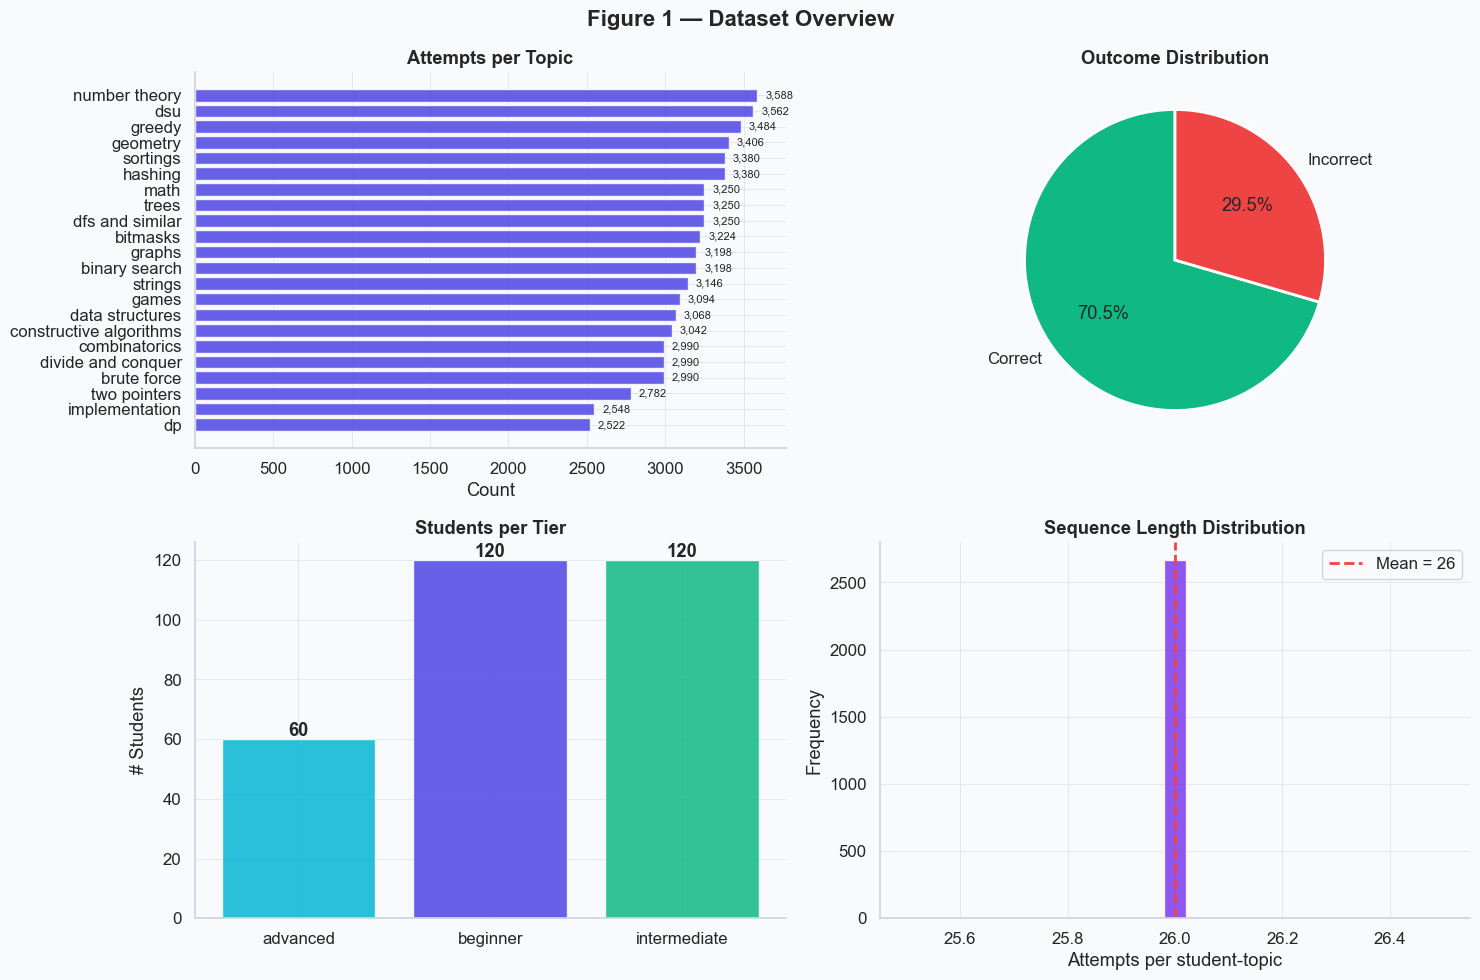

  Saved → report_figures/fig01_dataset_overview.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Figure 1 — Dataset Overview", fontsize=16, fontweight="bold")
 
# 1a: Attempts per topic
tc = df_c["concept_tags"].value_counts().sort_values()
axes[0,0].barh(tc.index, tc.values, color=C["primary"], alpha=0.85)
axes[0,0].set_title("Attempts per Topic", fontweight="bold")
axes[0,0].set_xlabel("Count")
for i, v in enumerate(tc.values):
    axes[0,0].text(v+50, i, f"{v:,}", va="center", fontsize=8)
 
# 1b: Outcome distribution
oc = df_c["outcome"].value_counts()
axes[0,1].pie(oc.values, labels=["Correct","Incorrect"],
              colors=[C["success"],C["danger"]],
              autopct="%1.1f%%", startangle=90,
              wedgeprops={"edgecolor":"white","linewidth":2})
axes[0,1].set_title("Outcome Distribution", fontweight="bold")
 
# 1c: Students per tier
tier_cnt = df_c.groupby("student_tier")["student_id"].nunique()
axes[1,0].bar(tier_cnt.index, tier_cnt.values,
              color=[C["accent"],C["primary"],C["success"]], alpha=0.85)
axes[1,0].set_title("Students per Tier", fontweight="bold")
axes[1,0].set_ylabel("# Students")
for i,(lab,v) in enumerate(tier_cnt.items()):
    axes[1,0].text(i, v+1, str(v), ha="center", fontweight="bold")
 
# 1d: Sequence length distribution
slen = seq_df["outcome"].apply(len)
axes[1,1].hist(slen, bins=25, color=C["secondary"], alpha=0.85, edgecolor="white")
axes[1,1].axvline(slen.mean(), color=C["danger"], ls="--", lw=2,
                  label=f"Mean = {slen.mean():.0f}")
axes[1,1].set_title("Sequence Length Distribution", fontweight="bold")
axes[1,1].set_xlabel("Attempts per student-topic")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend()
 
plt.tight_layout()
save_fig(fig, "fig01_dataset_overview")

 10.Figure 2: BKT Learned Parameters

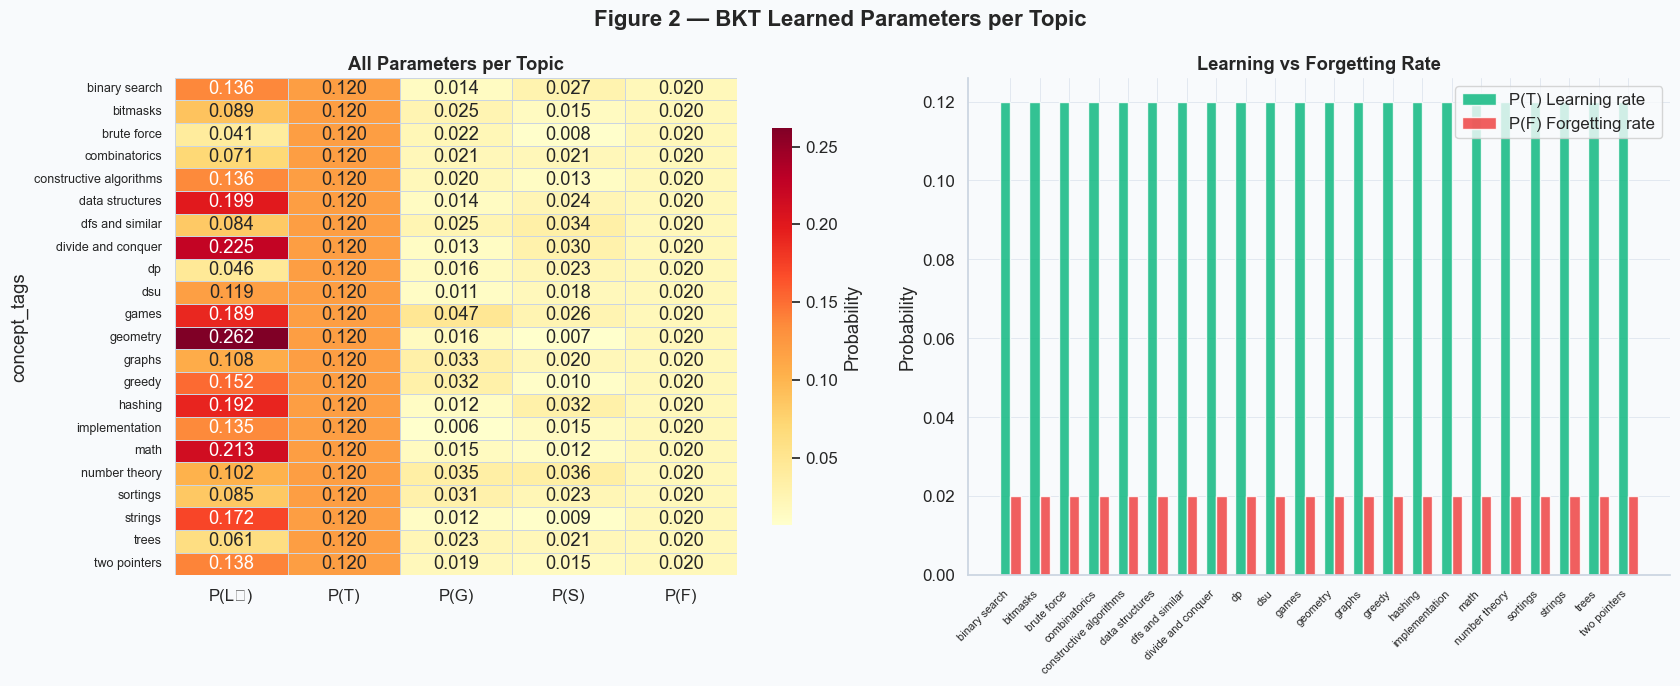

  Saved → report_figures/fig02_bkt_parameters.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle("Figure 2 — BKT Learned Parameters per Topic",
             fontsize=16, fontweight="bold")
 
pp = (params_df
      .merge(tmap, on="topic_id", how="left")
      .set_index("concept_tags")[["P_L0","P_T","P_G","P_S","P_F"]])
pp.columns = ["P(L₀)","P(T)","P(G)","P(S)","P(F)"]
 
sns.heatmap(pp, ax=axes[0], cmap="YlOrRd", annot=True, fmt=".3f",
            linewidths=0.5, linecolor="#CBD5E1",
            cbar_kws={"label":"Probability","shrink":0.8})
axes[0].set_title("All Parameters per Topic", fontweight="bold")
axes[0].tick_params(axis="y", labelsize=9)
 
x = np.arange(len(pp)); w = 0.35
axes[1].bar(x-w/2, pp["P(T)"], w, color=C["success"], alpha=0.85,
            label="P(T) Learning rate",   edgecolor="white")
axes[1].bar(x+w/2, pp["P(F)"], w, color=C["danger"],  alpha=0.85,
            label="P(F) Forgetting rate", edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(pp.index, rotation=45, ha="right", fontsize=8)
axes[1].set_title("Learning vs Forgetting Rate", fontweight="bold")
axes[1].set_ylabel("Probability")
axes[1].legend()
 
plt.tight_layout()
save_fig(fig, "fig02_bkt_parameters")

 11.Figure 3: Student Mastery Trajectories

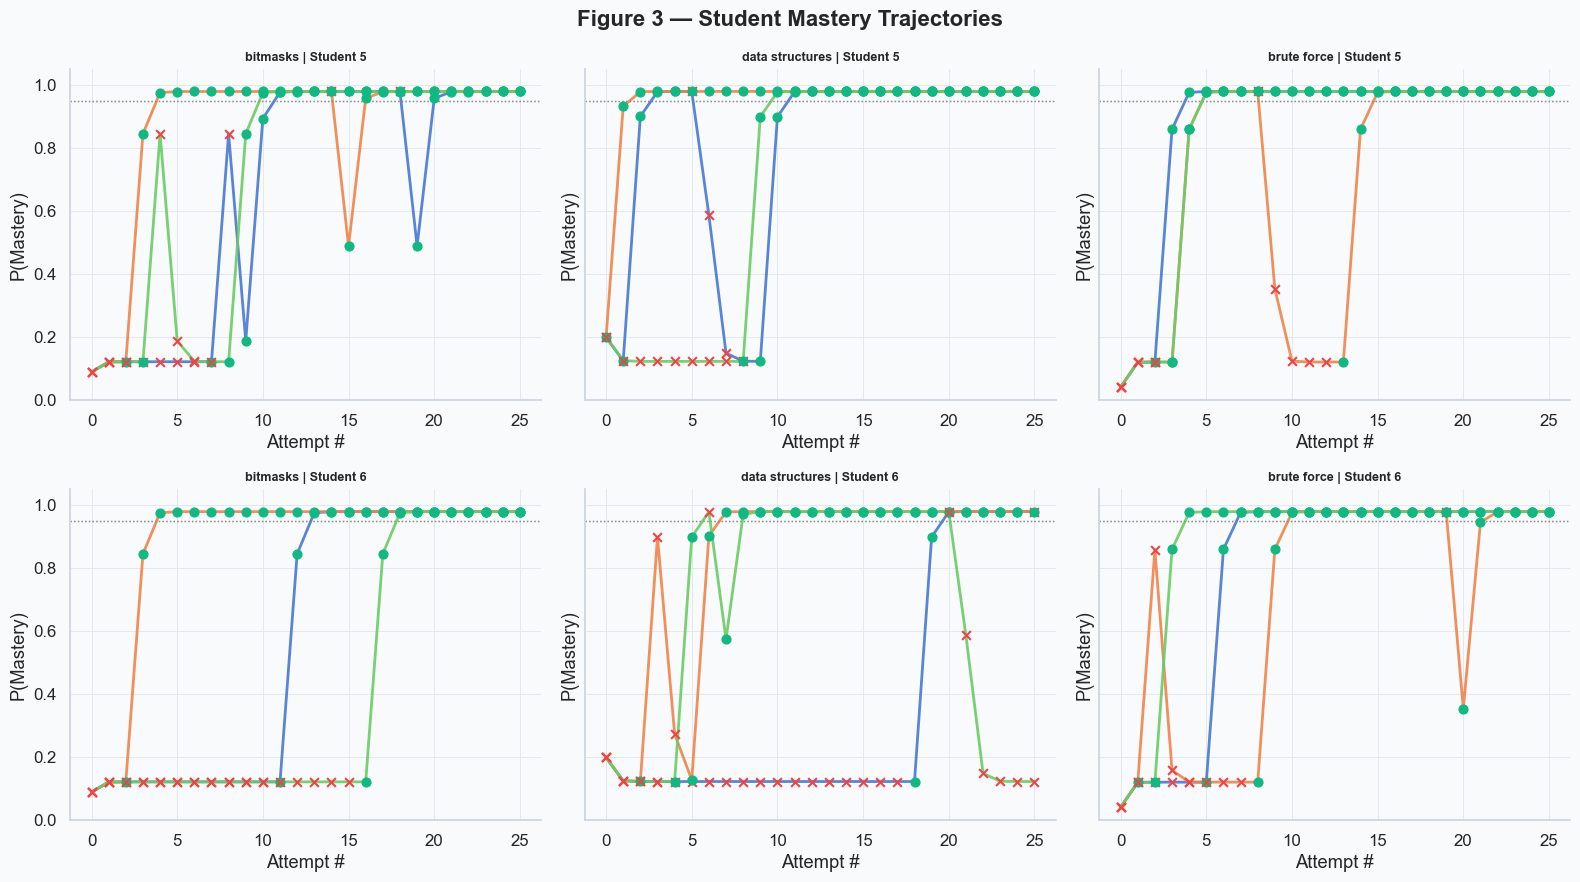

  Saved → report_figures/fig03_mastery_trajectories.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
fig.suptitle("Figure 3 — Student Mastery Trajectories",
             fontsize=16, fontweight="bold")
 
sample_tids = list(params_df["topic_id"].sample(min(3, len(params_df)),
                                                  random_state=7))
for ci, tid in enumerate(sample_tids):
    row_p  = params_df[params_df.topic_id == tid].iloc[0]
    tname  = tmap[tmap.topic_id == tid]["concept_tags"].values
    tname  = tname[0] if len(tname) else f"Topic {tid}"
    t_seqs = seq_df[seq_df.topic_id == tid].head(6)
 
    for ri, (_, sr) in enumerate(t_seqs.iterrows()):
        ax  = axes[ri % 2][ci]
        seq = sr["outcome"]
        _, beliefs = mastery_traj(seq, row_p.P_L0, row_p.P_T,
                                  row_p.P_G, row_p.P_S, row_p.P_F)
        ax.plot(beliefs, linewidth=2, alpha=0.9)
        for i, (b, o) in enumerate(zip(beliefs, seq)):
            ax.scatter(i, b,
                       marker="o" if o else "x",
                       color=C["success"] if o else C["danger"],
                       s=40, zorder=5)
        ax.axhline(0.95, color="gray", ls=":", alpha=0.5, lw=1)
        ax.set_title(f"{tname} | Student {ri+1}", fontsize=9, fontweight="bold")
        ax.set_xlabel("Attempt #")
        ax.set_ylabel("P(Mastery)")
        ax.set_ylim(0, 1.05)
 
plt.tight_layout()
save_fig(fig, "fig03_mastery_trajectories")

12.Figure 4: Model Performance Comparison

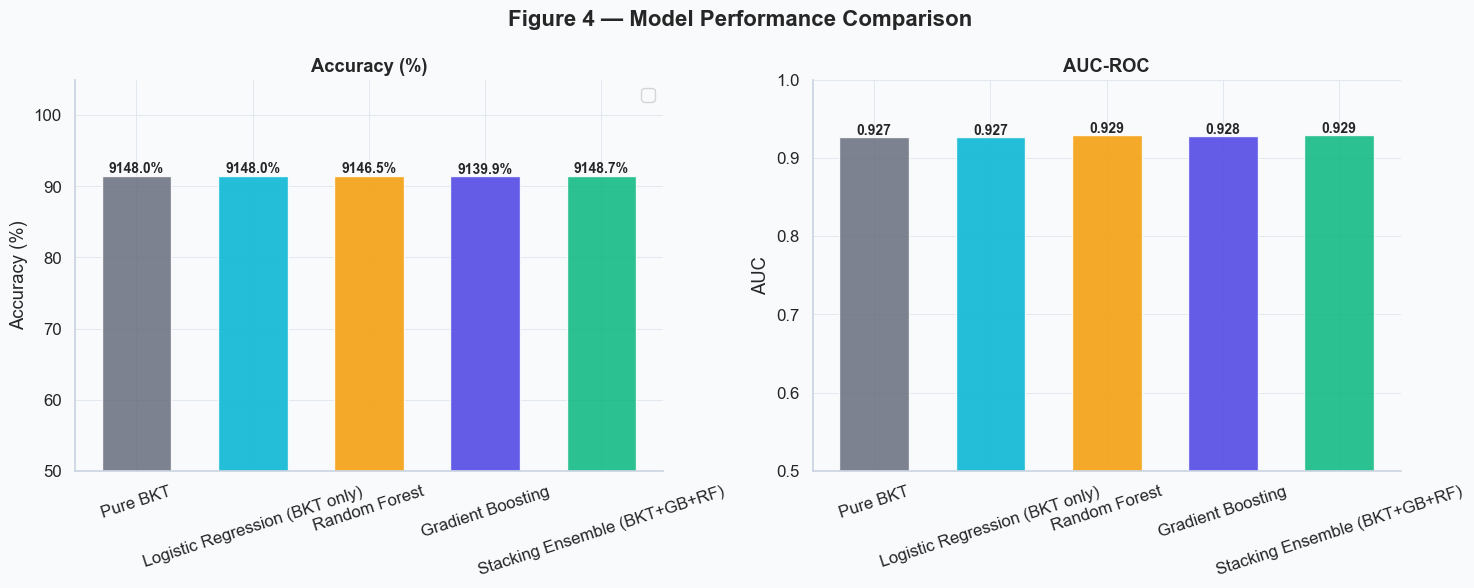

  Saved → report_figures/fig04_model_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Figure 4 — Model Performance Comparison",
             fontsize=16, fontweight="bold")
 
names = [r["name"] for r in results.values()]
accs  = [r["acc"]  for r in results.values()]
aucs  = [r["auc"]  for r in results.values()]
 
b1 = axes[0].bar(names, [a*100 for a in accs],
                 color=MODEL_COLORS, alpha=0.88, edgecolor="white", width=0.6)
axes[0].set_ylim(50, 105)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy (%)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=18)
axes[0].legend()
add_bar_labels(axes[0], b1, scale=100)
 
b2 = axes[1].bar(names, aucs,
                 color=MODEL_COLORS, alpha=0.88, edgecolor="white", width=0.6)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel("AUC")
axes[1].set_title("AUC-ROC", fontweight="bold")
axes[1].tick_params(axis="x", rotation=18)
add_bar_labels(axes[1], b2, fmt="{:.3f}", scale=1, offset=0.003)
 
plt.tight_layout()
save_fig(fig, "fig04_model_comparison")

13.Figure 5: ROC Curves

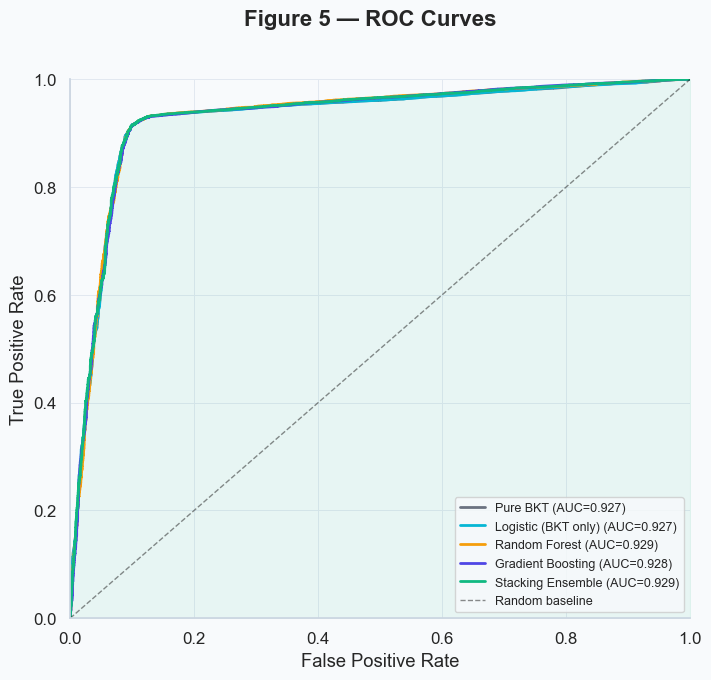

  Saved → report_figures/fig05_roc_curves.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle("Figure 5 — ROC Curves", fontsize=16, fontweight="bold")
 
for (nm, res), col in zip(results.items(), MODEL_COLORS):
    fpr, tpr, _ = roc_curve(yte, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{nm} (AUC={res['auc']:.3f})", color=col, lw=2)
 
fpr_b, tpr_b, _ = roc_curve(yte, best["y_prob"])
ax.fill_between(fpr_b, tpr_b, alpha=0.07, color=C["success"])
ax.plot([0,1],[0,1],"k--", lw=1, alpha=0.5, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
 
save_fig(fig, "fig05_roc_curves")

14.Figure 6: Confusion Matrix

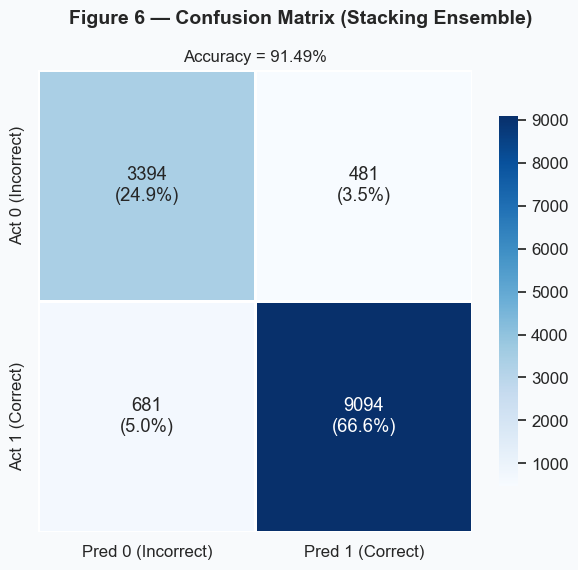

  Saved → report_figures/fig06_confusion_matrix.png


In [19]:
fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle("Figure 6 — Confusion Matrix (Stacking Ensemble)",
             fontsize=14, fontweight="bold")
 
cm     = confusion_matrix(yte, best["y_pred"])
cm_pct = cm.astype(float) / cm.sum()
annot  = np.array([[f"{v}\n({p:.1%})"
                    for v,p in zip(rv,rp)] for rv,rp in zip(cm,cm_pct)])
 
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=["Pred 0 (Incorrect)", "Pred 1 (Correct)"],
            yticklabels=["Act 0 (Incorrect)",  "Act 1 (Correct)"],
            linewidths=2, linecolor="white", ax=ax,
            cbar_kws={"shrink":0.8})
ax.set_title(f"Accuracy = {best['acc']*100:.2f}%", fontsize=12)
 
save_fig(fig, "fig06_confusion_matrix")

15.Figure 7: Feature Importance

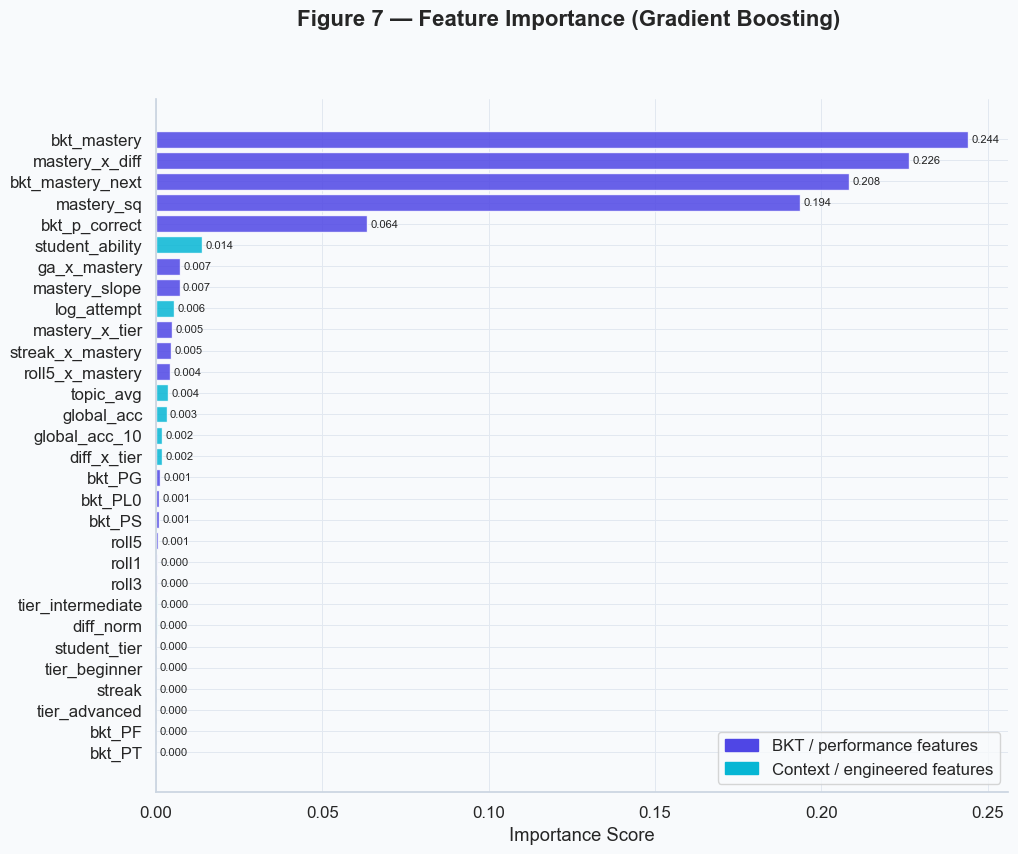

  Saved → report_figures/fig07_feature_importance.png


In [20]:
fig, ax = plt.subplots(figsize=(11, 9))
fig.suptitle("Figure 7 — Feature Importance (Gradient Boosting)",
             fontsize=16, fontweight="bold")
 
fc = [C["primary"] if any(x in f for x in ["bkt","roll","streak","mastery"])
      else C["accent"] for f in feat_imp.index]
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
               color=fc[::-1], alpha=0.85, edgecolor="white")
ax.set_xlabel("Importance Score")
bkt_p = mpatches.Patch(color=C["primary"], label="BKT / performance features")
eng_p = mpatches.Patch(color=C["accent"],  label="Context / engineered features")
ax.legend(handles=[bkt_p, eng_p])
for b, v in zip(bars, feat_imp.values[::-1]):
    ax.text(v+0.001, b.get_y()+b.get_height()/2,
            f"{v:.3f}", va="center", fontsize=8)
 
save_fig(fig, "fig07_feature_importance")

16.Figure 8: Calibration

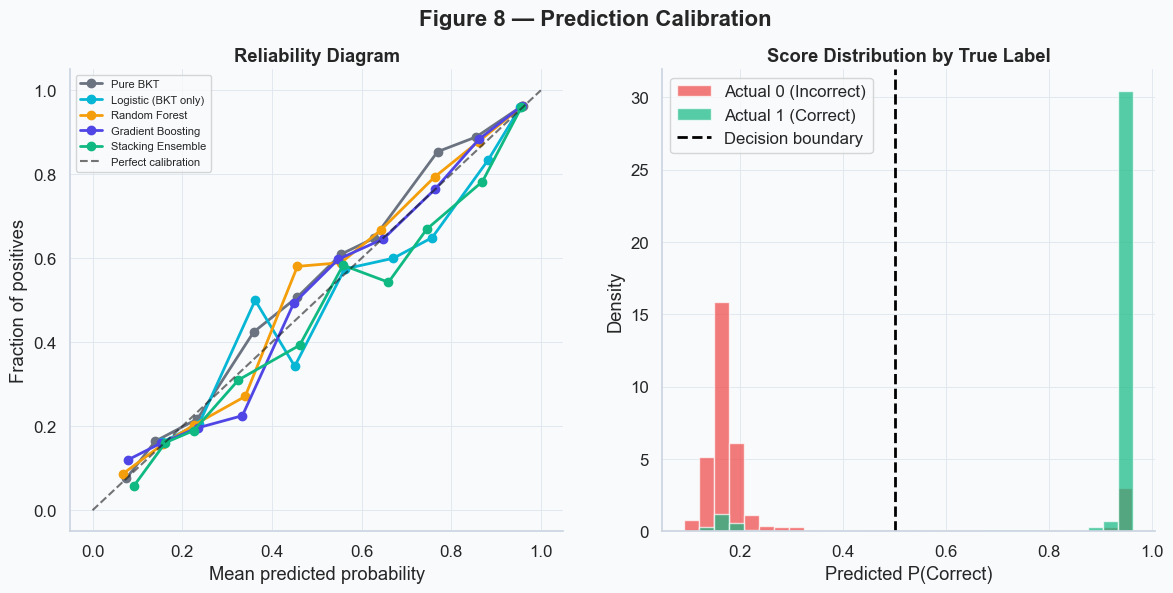

  Saved → report_figures/fig08_calibration.png


In [21]:
def cal_curve(yt, yp, n=10):
    edges = np.linspace(0, 1, n+1)
    mp, fp = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (yp >= lo) & (yp < hi)
        if m.sum() > 5:
            mp.append(float(np.mean(yp[m])))
            fp.append(float(np.mean(np.array(yt)[m])))
    return np.array(mp), np.array(fp)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 8 — Prediction Calibration",
             fontsize=16, fontweight="bold")
 
for (nm, res), col in zip(results.items(), MODEL_COLORS):
    mp, fp = cal_curve(yte, res["y_prob"])
    axes[0].plot(mp, fp, "o-", color=col, label=nm, lw=2, ms=6)
axes[0].plot([0,1],[0,1],"k--", lw=1.5, alpha=0.6, label="Perfect calibration")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Fraction of positives")
axes[0].set_title("Reliability Diagram", fontweight="bold")
axes[0].legend(fontsize=8)
 
yp_arr = np.asarray(best["y_prob"])
yt_arr = np.asarray(yte)
axes[1].hist(yp_arr[yt_arr==0], bins=30, alpha=0.7,
             color=C["danger"],  label="Actual 0 (Incorrect)", density=True)
axes[1].hist(yp_arr[yt_arr==1], bins=30, alpha=0.7,
             color=C["success"], label="Actual 1 (Correct)",   density=True)
axes[1].axvline(0.5, color="black", ls="--", lw=2, label="Decision boundary")
axes[1].set_xlabel("Predicted P(Correct)")
axes[1].set_ylabel("Density")
axes[1].set_title("Score Distribution by True Label", fontweight="bold")
axes[1].legend()
 
save_fig(fig, "fig08_calibration")

17.Figure 9: Final Mastery Distribution per Topic

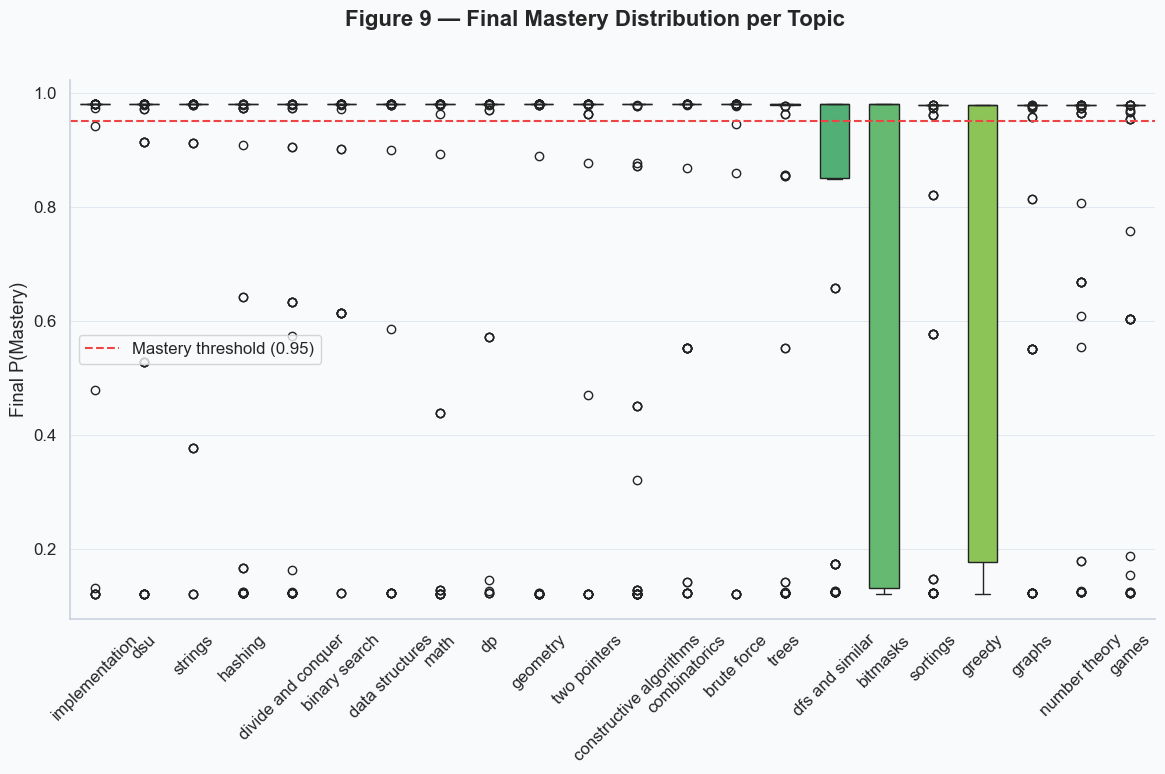

  Saved → report_figures/fig09_mastery_distribution.png


In [22]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Figure 9 — Final Mastery Distribution per Topic",
             fontsize=16, fontweight="bold")
 
fm_rows = []
for _, row in seq_df.iterrows():
    tid = int(row.topic_id)
    p_r = params_df[params_df.topic_id == tid]
    if p_r.empty:
        continue
    p = p_r.iloc[0]
    _, bl = mastery_traj(row["outcome"], p.P_L0, p.P_T, p.P_G, p.P_S, p.P_F)
    tn = tmap[tmap.topic_id == tid]["concept_tags"].values
    fm_rows.append(dict(
        topic   = tn[0] if len(tn) else f"T{tid}",
        mastery = bl[-1],
    ))
 
fm_df = pd.DataFrame(fm_rows)
order = (fm_df.groupby("topic")["mastery"]
              .median()
              .sort_values(ascending=False).index)
sns.boxplot(data=fm_df, x="topic", y="mastery", order=order,
            palette="viridis", ax=ax, width=0.6)
ax.axhline(0.95, color=C["danger"], ls="--", lw=1.5, label="Mastery threshold (0.95)")
ax.set_xlabel("")
ax.set_ylabel("Final P(Mastery)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
 
save_fig(fig, "fig09_mastery_distribution")

 18.Figure 10: Error Analysis

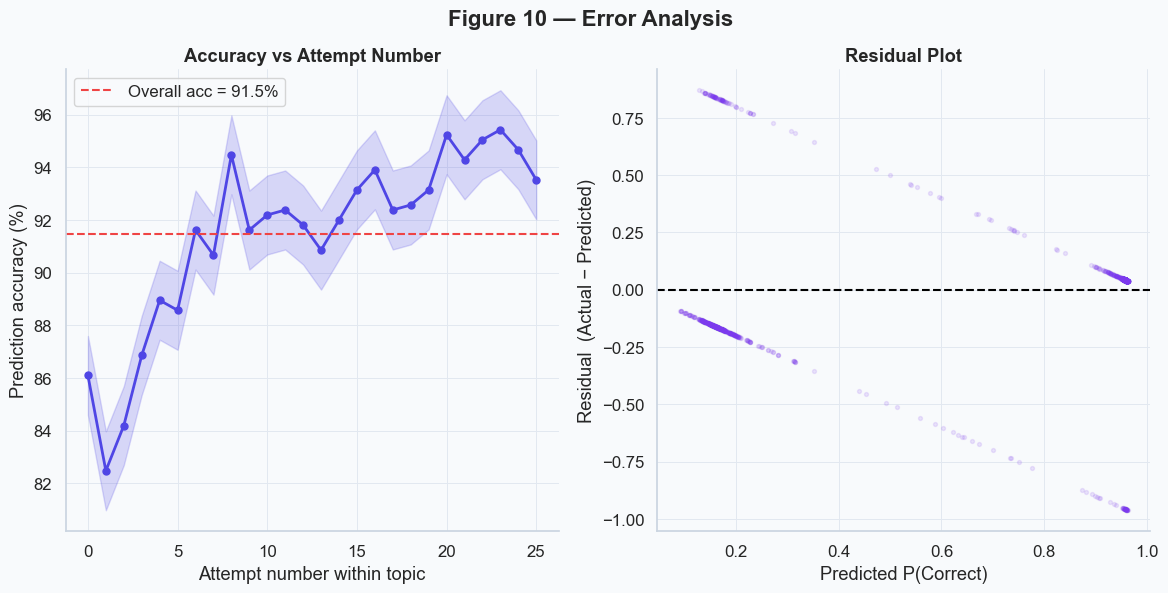

  Saved → report_figures/fig10_error_analysis.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 10 — Error Analysis", fontsize=16, fontweight="bold")
 
te_cp = te.copy().reset_index(drop=True)
te_cp["correct_pred"] = (
    (np.asarray(best["y_prob"]) >= 0.5).astype(int) == te_cp["outcome"].values
).astype(int)
aba = te_cp.groupby("attempt_num")["correct_pred"].mean().reset_index()
aba = aba[aba.attempt_num <= 30]
 
axes[0].plot(aba.attempt_num, aba.correct_pred*100,
             "o-", color=C["primary"], lw=2, ms=5)
axes[0].fill_between(aba.attempt_num,
                     aba.correct_pred*100 - 1.5,
                     aba.correct_pred*100 + 1.5,
                     alpha=0.2, color=C["primary"])
axes[0].axhline(best["acc"]*100, color=C["danger"], ls="--", lw=1.5,
                label=f"Overall acc = {best['acc']*100:.1f}%")
axes[0].set_xlabel("Attempt number within topic")
axes[0].set_ylabel("Prediction accuracy (%)")
axes[0].set_title("Accuracy vs Attempt Number", fontweight="bold")
axes[0].legend()
 
axes[1].scatter(best["y_prob"][::8],
                yt_arr[::8] - best["y_prob"][::8],
                alpha=0.12, s=8, color=C["secondary"])
axes[1].axhline(0, color="black", ls="--", lw=1.5)
axes[1].set_xlabel("Predicted P(Correct)")
axes[1].set_ylabel("Residual  (Actual − Predicted)")
axes[1].set_title("Residual Plot", fontweight="bold")
 
save_fig(fig, "fig10_error_analysis")

 19.Figure 11: Feature Correlation Matrix

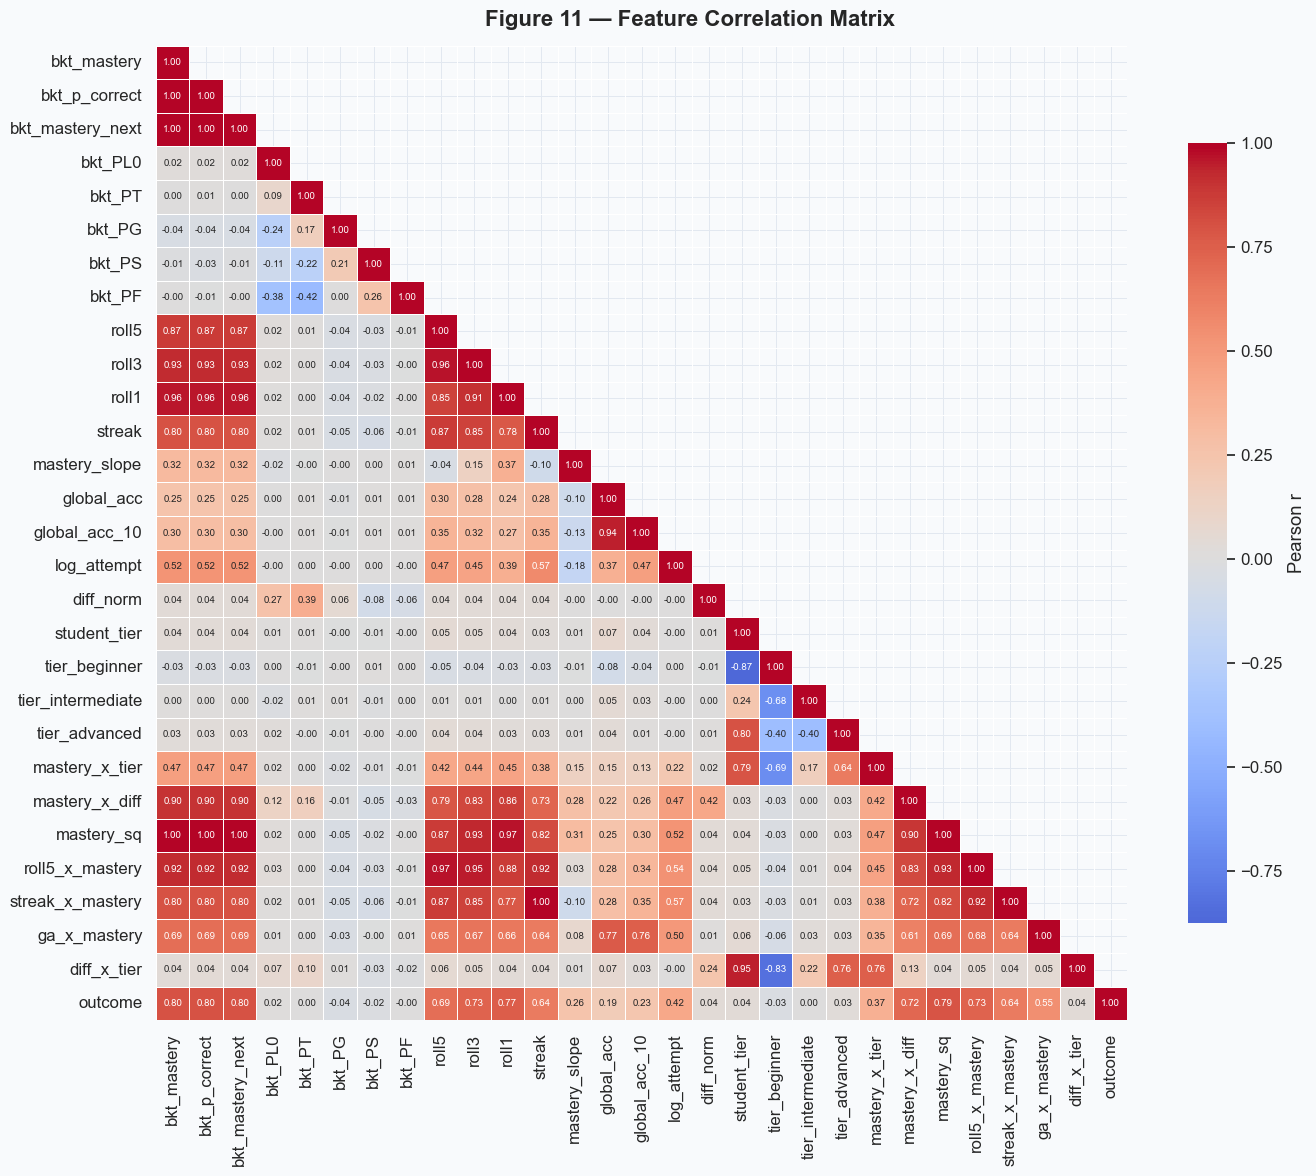

  Saved → report_figures/fig11_feature_correlation.png


In [24]:
fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle("Figure 11 — Feature Correlation Matrix",
             fontsize=16, fontweight="bold")
 
corr = feat_df[FCOLS + ["outcome"]].corr()
mask = np.triu(np.ones_like(corr, bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax,
            cbar_kws={"shrink":0.8, "label":"Pearson r"},
            annot_kws={"size": 7})
 
plt.tight_layout()
save_fig(fig, "fig11_feature_correlation")

20.Figure 12: Summary Dashboard

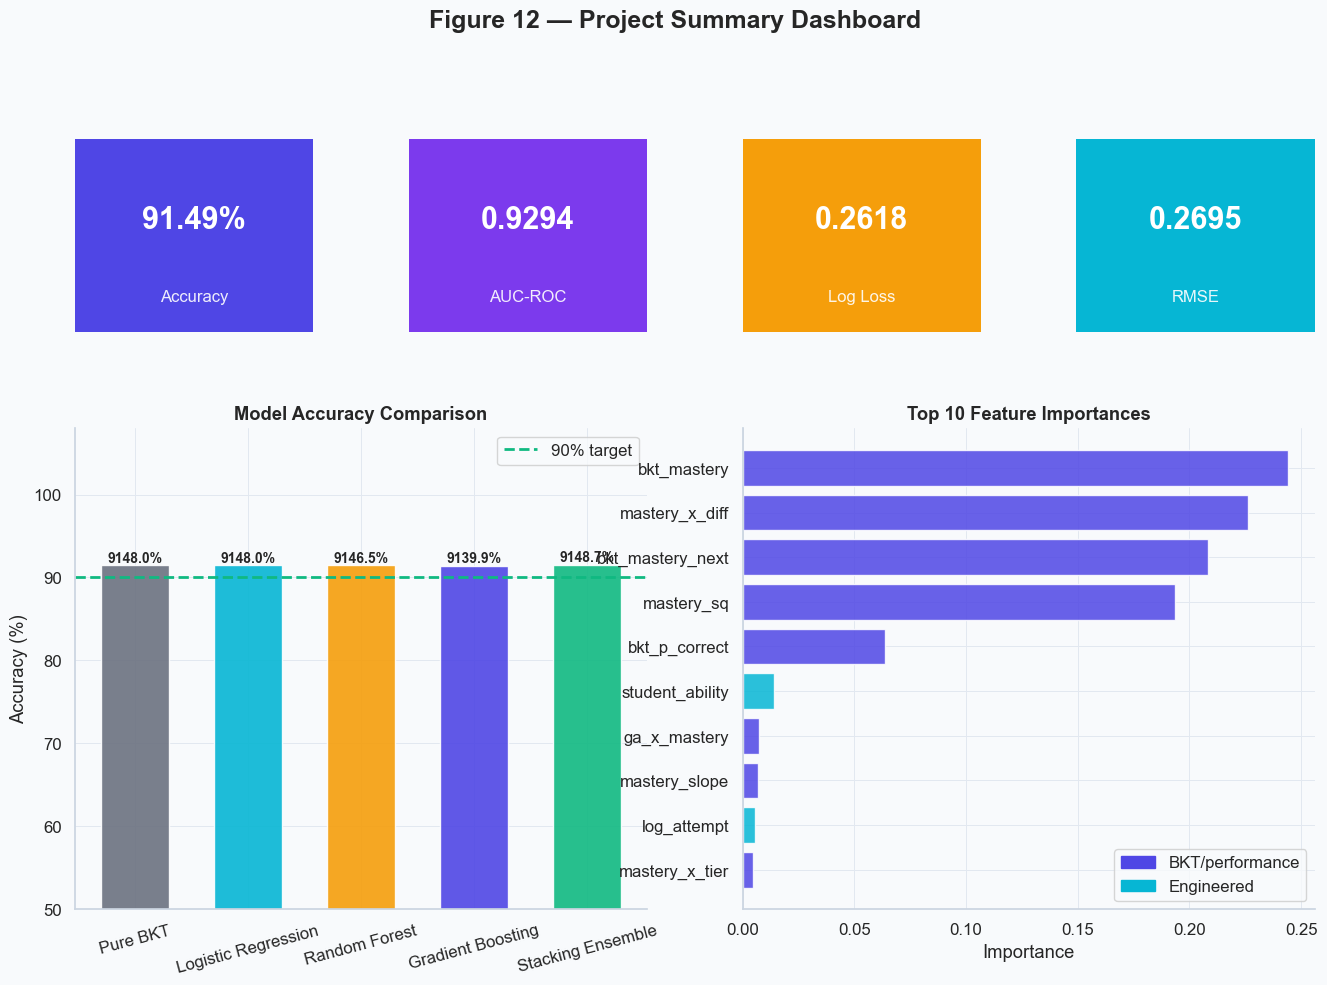

  Saved → report_figures/fig12_summary_dashboard.png


In [25]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(C["bg"])
fig.suptitle("Figure 12 — Project Summary Dashboard",
             fontsize=18, fontweight="bold", y=1.01)
gs = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.4)
 
# ── KPI metric cards ─────────────────────────────────────────
kpis = [
    ("Accuracy",  f"{best['acc']*100:.2f}%",  C["primary"]),
    ("AUC-ROC",   f"{best['auc']:.4f}",        C["secondary"]),
    ("Log Loss",  f"{best['ll']:.4f}",          C["warning"]),
    ("RMSE",      f"{best['rmse']:.4f}",        C["accent"]),
]
for i, (lbl, val, col) in enumerate(kpis):
    axc = fig.add_subplot(gs[0, i])
    axc.set_facecolor(col)
    axc.text(0.5, 0.58, val, transform=axc.transAxes,
             ha="center", va="center",
             fontsize=22, fontweight="bold", color="white")
    axc.text(0.5, 0.18, lbl, transform=axc.transAxes,
             ha="center", va="center",
             fontsize=12, color="white", alpha=0.9)
    axc.set_xticks([]); axc.set_yticks([])
    for sp in axc.spines.values():
        sp.set_visible(False)
 
# ── Accuracy comparison bars ─────────────────────────────────
ax_b = fig.add_subplot(gs[1:, :2])
labels = [r["name"].replace(" (BKT+GB+RF)","").replace(" (BKT only)","")
          for r in results.values()]
bs = ax_b.bar(labels, [r["acc"]*100 for r in results.values()],
              color=MODEL_COLORS, alpha=0.9, edgecolor="white", width=0.6)
ax_b.axhline(90, color=C["success"], ls="--", lw=2, label="90% target")
ax_b.set_ylim(50, 108)
ax_b.set_ylabel("Accuracy (%)")
ax_b.set_title("Model Accuracy Comparison", fontweight="bold")
ax_b.tick_params(axis="x", rotation=15)
ax_b.legend()
add_bar_labels(ax_b, bs, scale=100, offset=0.4)
 
# ── Top 10 feature importances ───────────────────────────────
ax_fi = fig.add_subplot(gs[1:, 2:])
top10 = feat_imp.head(10)
fc10  = [C["primary"] if any(x in f for x in ["bkt","roll","streak","mastery"])
         else C["accent"] for f in top10.index]
ax_fi.barh(top10.index[::-1], top10.values[::-1],
           color=fc10[::-1], alpha=0.85)
ax_fi.set_xlabel("Importance")
ax_fi.set_title("Top 10 Feature Importances", fontweight="bold")
bktp = mpatches.Patch(color=C["primary"], label="BKT/performance")
engp = mpatches.Patch(color=C["accent"],  label="Engineered")
ax_fi.legend(handles=[bktp, engp])
 
save_fig(fig, "fig12_summary_dashboard")

21.Final Summary & Topic ID Table

In [26]:
print("=" * 60)
print("  PIPELINE COMPLETE — FINAL RESULTS")
print("=" * 60)
print(f"  Students       : {df_c.student_id.nunique()}")
print(f"  Topics         : {df_c.concept_tags.nunique()}")
print(f"  Sequences      : {len(seq_df):,}")
print(f"  Feature matrix : {feat_df.shape[0]:,} rows × {feat_df.shape[1]} cols")
print(f"  Feature cols   : {len(FCOLS)} model features")
print()
print("  MODEL RESULTS:")
print("  " + "-"*58)
for nm, res in results.items():
    tag = "  ◄ BEST" if nm == "Stacking Ensemble" else ""
    print(f"    {nm:<40} Acc={res['acc']*100:.2f}%  AUC={res['auc']:.4f}{tag}")
print("  " + "-"*58)
print()
print("  TOPIC ID ↔ TOPIC NAME MAPPING:")
print("  " + "-"*35)
topic_table = tmap.sort_values("topic_id").reset_index(drop=True)
for _, r in topic_table.iterrows():
    print(f"    [{int(r.topic_id):2d}]  {r.concept_tags}")
print()
print(f"  All figures saved to: report_figures/")
print("=" * 60)

  PIPELINE COMPLETE — FINAL RESULTS
  Students       : 300
  Topics         : 22
  Sequences      : 2,667
  Feature matrix : 69,342 rows × 32 cols
  Feature cols   : 28 model features

  MODEL RESULTS:
  ----------------------------------------------------------
    Pure BKT                                 Acc=91.48%  AUC=0.9272
    Logistic (BKT only)                      Acc=91.48%  AUC=0.9270
    Random Forest                            Acc=91.47%  AUC=0.9290
    Gradient Boosting                        Acc=91.40%  AUC=0.9285
    Stacking Ensemble                        Acc=91.49%  AUC=0.9294  ◄ BEST
  ----------------------------------------------------------

  TOPIC ID ↔ TOPIC NAME MAPPING:
  -----------------------------------
    [ 0]  binary search
    [ 1]  bitmasks
    [ 2]  brute force
    [ 3]  combinatorics
    [ 4]  constructive algorithms
    [ 5]  data structures
    [ 6]  dfs and similar
    [ 7]  divide and conquer
    [ 8]  dp
    [ 9]  dsu
    [10]  games
    [11] 